# Notebook V8 - PAMAP2 (Initialisation + EDA)

Objectif de cette V8: poser une base propre sur le dataset PAMAP2, reproduire la phase initialisation comme les versions precedentes, puis faire une EDA claire pour orienter la suite du modele.

## Plan
1. Imports et configuration
2. Chargement PAMAP2 (UCI)
3. Verifications de base
4. EDA en tableaux + dataviz

In [62]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

BASE_DIR = Path("/home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML")
BASE_DIR.mkdir(parents=True, exist_ok=True)
print(f"BASE_DIR: {BASE_DIR}")

BASE_DIR: /home/aldarion/Documents/projet_soutenance/trainer/github/projet-soutenance-Alyra/1 - ML


## Chargement des donnees PAMAP2

Note: PAMAP2 n'est pas importable directement via `ucimlrepo` (DatasetNotFoundError). On charge donc les fichiers locaux `.dat` du dataset officiel.

In [63]:
# Chargement PAMAP2 - Protocol uniquement
from glob import glob

PAMAP2_COLS = [
    "timestamp", "activity_id", "heart_rate",
    "hand_temp", "hand_acc16_x", "hand_acc16_y", "hand_acc16_z",
    "hand_acc6_x", "hand_acc6_y", "hand_acc6_z",
    "hand_gyro_x", "hand_gyro_y", "hand_gyro_z",
    "hand_mag_x", "hand_mag_y", "hand_mag_z",
    "hand_orient_1", "hand_orient_2", "hand_orient_3", "hand_orient_4",
    "chest_temp", "chest_acc16_x", "chest_acc16_y", "chest_acc16_z",
    "chest_acc6_x", "chest_acc6_y", "chest_acc6_z",
    "chest_gyro_x", "chest_gyro_y", "chest_gyro_z",
    "chest_mag_x", "chest_mag_y", "chest_mag_z",
    "chest_orient_1", "chest_orient_2", "chest_orient_3", "chest_orient_4",
    "ankle_temp", "ankle_acc16_x", "ankle_acc16_y", "ankle_acc16_z",
    "ankle_acc6_x", "ankle_acc6_y", "ankle_acc6_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "ankle_orient_1", "ankle_orient_2", "ankle_orient_3", "ankle_orient_4"
]

dataset_root = BASE_DIR / "PAMAP2_Dataset"
protocol_files = sorted(glob(str(dataset_root / "Protocol" / "subject*.dat")))

frames = []
for fp in protocol_files:
    sid = int(Path(fp).stem.replace("subject", ""))
    tmp = pd.read_csv(fp, sep=r"\s+", header=None, names=PAMAP2_COLS, na_values=["NaN"], engine="python")
    tmp["subject_id"] = sid
    frames.append(tmp)

df_raw = pd.concat(frames, ignore_index=True)
df_raw["activity_id"] = pd.to_numeric(df_raw["activity_id"], errors="coerce").astype("Int64")

print(f"Sujets protocol: {df_raw['subject_id'].nunique()} | Lignes: {len(df_raw):,}")
df_raw.head(3)


Sujets protocol: 9 | Lignes: 2,872,533


,timestamp,activity_id,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orient_1,hand_orient_2,hand_orient_3,hand_orient_4,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orient_1,chest_orient_2,chest_orient_3,chest_orient_4,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orient_1,ankle_orient_2,ankle_orient_3,ankle_orient_4,subject_id
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,-0.092217,0.056812,-0.015845,14.6806,-69.2128,-5.58905,1.0,0.0,0.0,0.0,31.8125,0.238080,9.80003,-1.68896,0.265304,9.81549,-1.41344,-0.005065,-0.006781,-0.005663,0.471960,-51.0499,43.2903,1.0,0.0,0.0,0.0,30.3125,9.65918,-1.65569,-0.099797,9.64689,-1.55576,0.310404,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,-0.024413,0.047759,0.006474,14.8991,-69.2224,-5.82311,1.0,0.0,0.0,0.0,31.8125,0.319530,9.61282,-1.49328,0.234939,9.78539,-1.42846,0.013685,0.001486,-0.041522,1.016900,-50.3966,43.1768,1.0,0.0,0.0,0.0,30.3125,9.69370,-1.57902,-0.215687,9.61670,-1.61630,0.280488,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,101
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,-0.057976,0.032574,-0.006988,14.2420,-69.5197,-5.12442,1.0,0.0,0.0,0.0,31.8125,0.235593,9.72421,-1.76621,0.173850,9.72528,-1.51894,-0.039923,0.034056,-0.002113,0.383136,-51.8336,43.7782,1.0,0.0,0.0,0.0,30.3125,9.58944,-1.73276,0.092914,9.63173,-1.58605,0.280311,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,101


In [64]:
# Découverte initiale du dataset (sans supposer les features)
print("Dimensions :", df_raw.shape)
print("\nColonnes :")
display(pd.DataFrame({"feature": df_raw.columns}))

print("\nAperçu des 5 premières lignes :")
display(df_raw.head())


Dimensions : (2872533, 55)

Colonnes :


,feature
0,timestamp
1,activity_id
2,heart_rate
3,hand_temp
4,hand_acc16_x
5,hand_acc16_y
6,hand_acc16_z
7,hand_acc6_x
8,hand_acc6_y
9,hand_acc6_z



Aperçu des 5 premières lignes :


,timestamp,activity_id,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,hand_orient_1,hand_orient_2,hand_orient_3,hand_orient_4,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,chest_orient_1,chest_orient_2,chest_orient_3,chest_orient_4,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_orient_1,ankle_orient_2,ankle_orient_3,ankle_orient_4,subject_id
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,-0.092217,0.056812,-0.015845,14.6806,-69.2128,-5.58905,1.0,0.0,0.0,0.0,31.8125,0.238080,9.80003,-1.68896,0.265304,9.81549,-1.41344,-0.005065,-0.006781,-0.005663,0.471960,-51.0499,43.2903,1.0,0.0,0.0,0.0,30.3125,9.65918,-1.65569,-0.099797,9.64689,-1.55576,0.310404,0.008300,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,-0.024413,0.047759,0.006474,14.8991,-69.2224,-5.82311,1.0,0.0,0.0,0.0,31.8125,0.319530,9.61282,-1.49328,0.234939,9.78539,-1.42846,0.013685,0.001486,-0.041522,1.016900,-50.3966,43.1768,1.0,0.0,0.0,0.0,30.3125,9.69370,-1.57902,-0.215687,9.61670,-1.61630,0.280488,-0.006577,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,101
2,8.40,0,NaN,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,-0.057976,0.032574,-0.006988,14.2420,-69.5197,-5.12442,1.0,0.0,0.0,0.0,31.8125,0.235593,9.72421,-1.76621,0.173850,9.72528,-1.51894,-0.039923,0.034056,-0.002113,0.383136,-51.8336,43.7782,1.0,0.0,0.0,0.0,30.3125,9.58944,-1.73276,0.092914,9.63173,-1.58605,0.280311,0.003014,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,101
3,8.41,0,NaN,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,-0.002352,0.032810,-0.003747,14.8908,-69.5439,-6.17367,1.0,0.0,0.0,0.0,31.8125,0.388697,9.53572,-1.72410,0.157969,9.64994,-1.57952,0.007513,-0.010498,-0.020684,0.315400,-49.8144,43.1670,1.0,0.0,0.0,0.0,30.3125,9.58814,-1.77040,0.054545,9.63197,-1.63135,0.340997,0.003175,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,101
4,8.42,0,NaN,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,0.012269,0.018305,-0.053325,15.5612,-68.8196,-6.28927,1.0,0.0,0.0,0.0,31.8125,0.315800,9.49908,-1.60914,0.233506,9.57411,-1.44418,-0.003822,-0.011217,-0.025975,-0.297733,-51.8097,43.6453,1.0,0.0,0.0,0.0,30.3125,9.69771,-1.65625,-0.060809,9.64699,-1.64647,0.340965,0.012698,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,101


In [65]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    "feature": df_raw.columns,
    "missing_count": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean() * 100).round(2).values
}).sort_values("missing_count", ascending=False)

# Affiche seulement les colonnes qui ont des NaN
missing_only = missing[missing["missing_count"] > 0].reset_index(drop=True)
display(missing_only)

print(f"Colonnes avec NaN : {len(missing_only)} / {df_raw.shape[1]}")
print(f"Total NaN dans le dataset : {int(df_raw.isna().sum().sum())}")


,feature,missing_count,missing_pct
0,heart_rate,2610265,90.87
1,hand_acc16_x,13141,0.46
2,hand_temp,13141,0.46
3,hand_acc16_y,13141,0.46
4,hand_acc16_z,13141,0.46
5,hand_acc6_y,13141,0.46
6,hand_acc6_x,13141,0.46
7,hand_mag_z,13141,0.46
8,hand_orient_1,13141,0.46
9,hand_acc6_z,13141,0.46


Colonnes avec NaN : 52 / 55
Total NaN dans le dataset : 3093966


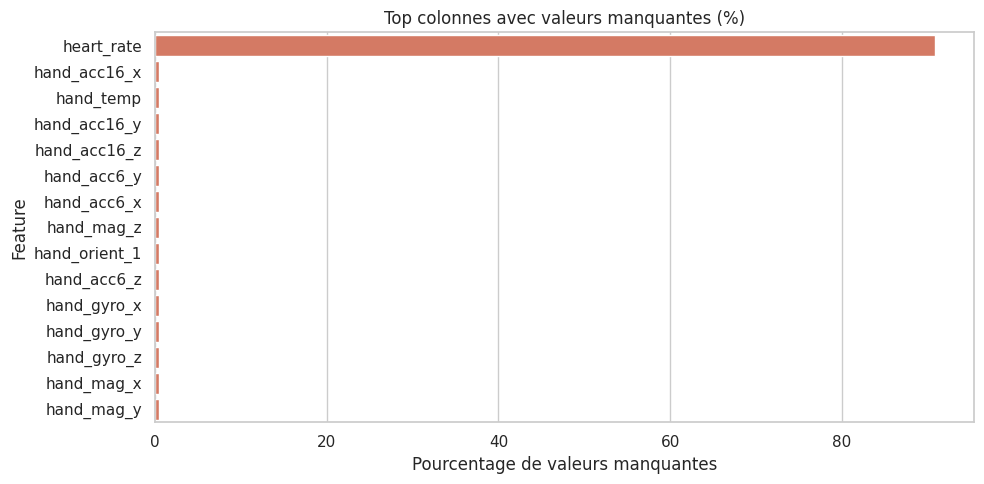

In [66]:
# Graphique clair: top colonnes avec le plus de valeurs manquantes
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

top_missing = missing_only.head(15)  # ajuste 15 si besoin
plt.figure(figsize=(10, 5))
sns.barplot(data=top_missing, x="missing_pct", y="feature", color="#E76F51")
plt.title("Top colonnes avec valeurs manquantes (%)")
plt.xlabel("Pourcentage de valeurs manquantes")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## On explique 90% de valeurs manquante sur le heart rate car 9Hz vs 100Hz pour les capteurs acceleros

In [67]:
# Détection robuste des colonnes timestamp et heart_rate
ts_col = "timestamp" if "timestamp" in df_raw.columns else df_raw.columns[0]
hr_col = "heart_rate" if "heart_rate" in df_raw.columns else df_raw.columns[2]

# Imputation HR par sujet
df_raw = df_raw.sort_values(["subject_id", ts_col]).copy()
df_raw[hr_col] = df_raw.groupby("subject_id")[hr_col].transform(lambda s: s.ffill().bfill())

print("Colonne timestamp utilisée :", ts_col)
print("Colonne heart_rate utilisée :", hr_col)
print("NaN restants heart_rate :", int(df_raw[hr_col].isna().sum()))


Colonne timestamp utilisée : timestamp
Colonne heart_rate utilisée : heart_rate
NaN restants heart_rate : 0


In [68]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    "feature": df_raw.columns,
    "missing_count": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean() * 100).round(2).values
}).sort_values("missing_count", ascending=False)

# Affiche seulement les colonnes qui ont des NaN
missing_only = missing[missing["missing_count"] > 0].reset_index(drop=True)
display(missing_only)

print(f"Colonnes avec NaN : {len(missing_only)} / {df_raw.shape[1]}")
print(f"Total NaN dans le dataset : {int(df_raw.isna().sum().sum())}")


,feature,missing_count,missing_pct
0,hand_acc16_y,13141,0.46
1,hand_acc16_x,13141,0.46
2,hand_temp,13141,0.46
3,hand_acc16_z,13141,0.46
4,hand_acc6_z,13141,0.46
5,hand_acc6_y,13141,0.46
6,hand_acc6_x,13141,0.46
7,hand_mag_z,13141,0.46
8,hand_orient_1,13141,0.46
9,hand_orient_2,13141,0.46


Colonnes avec NaN : 51 / 55
Total NaN dans le dataset : 483701


## On retire les orient_* et on remplace par des valeurs medianes les valeurs manquantes car uniquement <1% max pour chaque features

In [69]:
# Nettoyage: drop orient_* puis imputation médiane (numériques)
import numpy as np

# 1) Suppression des colonnes d'orientation
orient_cols = [c for c in df_raw.columns if "orient_" in str(c)]
df_clean = df_raw.drop(columns=orient_cols).copy()

# 2) Imputation médiane sur colonnes numériques
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

print(f"Colonnes supprimées (orient): {len(orient_cols)}")
print(f"Shape après nettoyage: {df_clean.shape}")
print("NaN restants:", int(df_clean.isna().sum().sum()))


Colonnes supprimées (orient): 12
Shape après nettoyage: (2872533, 43)
NaN restants: 0


## On retire la cible

In [70]:
# Cible + filtre des transitions
df_model = df_clean[df_clean["activity_id"] != 0].copy()

y = df_model["activity_id"]
X = df_model.drop(columns=["activity_id"])

print("Shape X:", X.shape, "| Classes y:", y.nunique())
print("Classes:", sorted(y.dropna().unique()))


Shape X: (1942872, 42) | Classes y: 12
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]


## Normalisation / Standardisation avec standard scaler

In [71]:
from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include="number").columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

X.head()


,timestamp,heart_rate,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,hand_mag_x,hand_mag_y,hand_mag_z,chest_temp,chest_acc16_x,chest_acc16_y,chest_acc16_z,chest_acc6_x,chest_acc6_y,chest_acc6_z,chest_gyro_x,chest_gyro_y,chest_gyro_z,chest_mag_x,chest_mag_y,chest_mag_z,ankle_temp,ankle_acc16_x,ankle_acc16_y,ankle_acc16_z,ankle_acc6_x,ankle_acc6_y,ankle_acc6_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,subject_id
2928,-1.525011,-0.277279,-1.334385,1.152065,0.684157,0.501860,1.145243,0.758982,0.503435,-0.004045,-0.002237,-0.005599,-0.511248,-2.231802,0.220854,-2.671552,-0.119921,0.306155,-0.042085,-0.031848,0.321978,-0.073665,0.069143,0.008567,-0.094160,-0.228861,-1.145648,1.838943,-2.71977,0.051140,-0.218969,0.683576,0.042278,-0.239508,0.702786,-0.006834,0.013996,-0.002954,-1.612155,-1.768779,-3.842566,-1.528636
2929,-1.525002,-0.277279,-1.334385,1.164402,0.595884,0.541651,1.149559,0.696864,0.507490,-0.130084,-0.014954,-0.004589,-0.483832,-2.232870,0.174281,-2.671552,-0.076152,0.306108,-0.041795,-0.040394,0.328214,-0.073627,0.030607,-0.063867,-0.116397,-0.209050,-1.133157,1.805112,-2.71977,0.044860,-0.223729,0.654068,0.034827,-0.237405,0.698479,0.009149,0.059008,-0.000834,-1.600335,-1.743646,-3.842363,-1.528636
2930,-1.524993,-0.277279,-1.334385,1.164231,0.518647,0.561593,1.148904,0.623282,0.507762,-0.180309,-0.029947,0.001928,-0.506061,-2.209836,0.244161,-2.671552,-0.036209,0.321155,-0.090380,-0.031419,0.334419,-0.060953,-0.015592,0.047400,-0.074207,-0.235441,-1.145306,1.827502,-2.71977,0.044662,-0.228602,0.644304,0.037381,-0.235279,0.728973,-0.040894,-0.024811,-0.006259,-1.570259,-1.718901,-3.854879,-1.528636
2931,-1.524983,-0.277279,-1.334385,1.152499,0.518829,0.580807,1.141205,0.561259,0.531023,-0.146090,-0.021707,0.009813,-0.469346,-2.211367,0.191686,-2.671552,-0.055467,0.321393,-0.057974,-0.014315,0.331303,-0.070507,0.026012,-0.106841,-0.164027,-0.243144,-1.112979,1.810408,-2.71977,0.039655,-0.218908,0.683380,0.034868,-0.241608,0.715953,-0.038334,0.027928,0.009598,-1.593402,-1.779832,-3.817681,-1.528636
2932,-1.524974,-0.277279,-1.334385,1.165866,0.535561,0.629752,1.138862,0.558986,0.550221,-0.053273,-0.060994,0.004286,-0.501803,-2.200767,0.215357,-2.671552,0.010843,0.321372,-0.049403,-0.014795,0.318868,-0.086386,-0.011805,-0.044453,-0.051662,-0.235040,-1.144741,1.776388,-2.71977,0.056852,-0.223915,0.683734,0.044779,-0.237395,0.711472,-0.008219,-0.019245,-0.006979,-1.562796,-1.780742,-3.817925,-1.528636


## Matrice de correclation

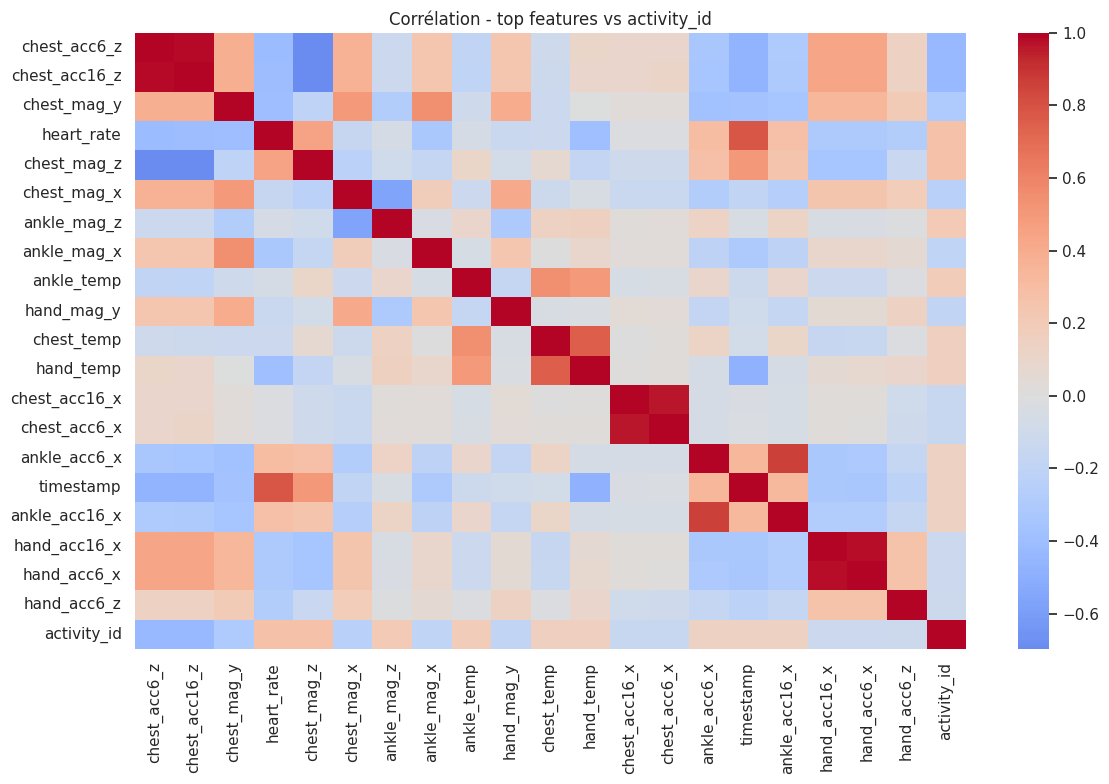

,abs_corr_with_activity_id
chest_acc6_z,0.429279
chest_acc16_z,0.428210
chest_mag_y,0.298333
heart_rate,0.265285
chest_mag_z,0.265201
chest_mag_x,0.241262
ankle_mag_z,0.209349
ankle_mag_x,0.199028
ankle_temp,0.196692
hand_mag_y,0.188350


In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 20 features numériques les plus corrélées à activity_id (valeur absolue)
corr_all = df_model.select_dtypes(include="number").corr(numeric_only=True)
corr_target = corr_all["activity_id"].drop("activity_id").abs().sort_values(ascending=False)
top_feats = corr_target.head(20).index.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df_model[top_feats + ["activity_id"]].corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Corrélation - top features vs activity_id")
plt.tight_layout()
plt.show()

display(corr_target.head(20).to_frame("abs_corr_with_activity_id"))


Ce qu'on apprend ici :
- Pas de features seule pour déduire l'activité
- Plusieurs campteurs apporte une info complémentaire
- certaines variables sont redondantes
- Timestamp peut apporter un biais et faire apprendre au modele la séquence dans le temps

## Split train/test

In [73]:
# Split par sujet: 7 train / 2 test (reproductible)
import numpy as np

subjects = sorted(df_model["subject_id"].dropna().unique())
rng = np.random.default_rng(42)

test_subjects = sorted(rng.choice(subjects, size=2, replace=False))
train_subjects = sorted([s for s in subjects if s not in test_subjects])

train_mask = df_model["subject_id"].isin(train_subjects)
test_mask = df_model["subject_id"].isin(test_subjects)

# On retire subject_id des features pour éviter la fuite d'identité
feature_cols = [c for c in df_model.columns if c not in ["activity_id", "subject_id"]]

X_train = df_model.loc[train_mask, feature_cols].copy()
y_train = df_model.loc[train_mask, "activity_id"].copy()

X_test = df_model.loc[test_mask, feature_cols].copy()
y_test = df_model.loc[test_mask, "activity_id"].copy()

print("Train subjects:", train_subjects)
print("Test subjects :", test_subjects)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Classes train:", sorted(y_train.unique()))
print("Classes test :", sorted(y_test.unique()))


Train subjects: [np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(109)]
Test subjects : [np.int64(101), np.int64(107)]
X_train: (1460139, 41) | X_test: (482733, 41)
Classes train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
Classes test : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]


## Entrainement et Matrice de correlation 

Features retirées: ['timestamp']
F1-macro: 0.5866
Balanced accuracy: 0.6039

Classification report:
              precision    recall  f1-score   support

         1.0       0.71      0.98      0.82     52798
         2.0       0.70      0.34      0.46     35762
         3.0       0.85      0.49      0.62     47468
         4.0       0.56      0.69      0.61     55973
         5.0       0.61      0.84      0.71     24957
         6.0       0.98      0.90      0.94     46255
         7.0       0.79      0.28      0.42     48990
        12.0       0.30      0.64      0.41     33536
        13.0       0.43      0.41      0.42     26517
        16.0       0.89      0.70      0.79     44493
        17.0       0.76      0.98      0.86     53072
        24.0       0.03      0.00      0.00     12912

    accuracy                           0.66    482733
   macro avg       0.63      0.60      0.59    482733
weighted avg       0.69      0.66      0.64    482733



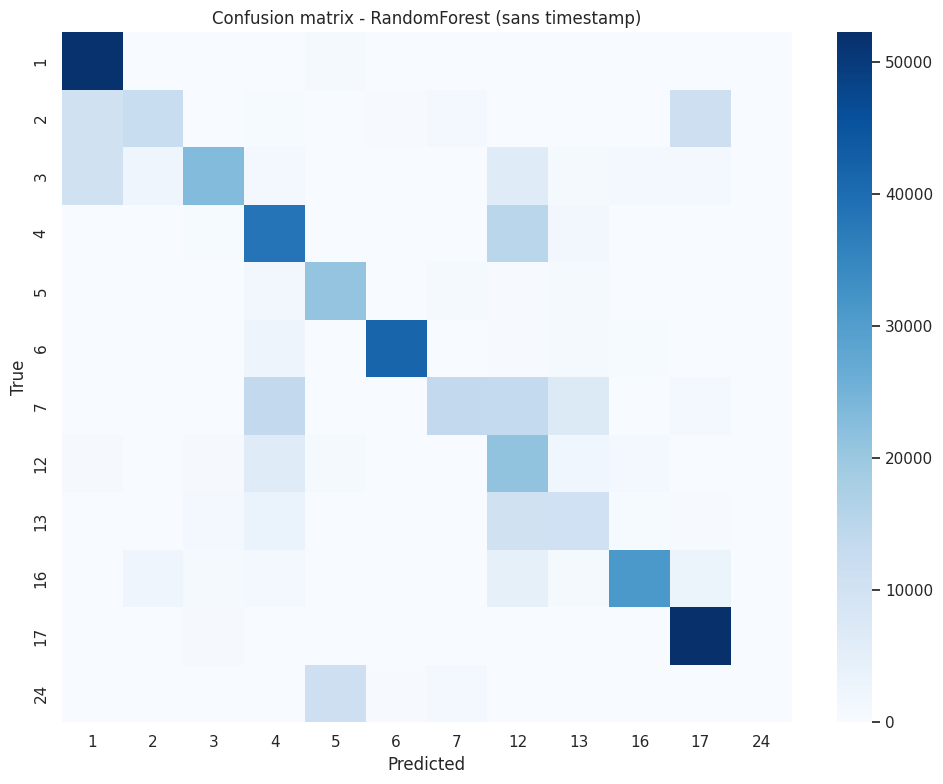

,importance
heart_rate,0.118024
hand_temp,0.101210
chest_temp,0.096849
ankle_temp,0.084925
chest_mag_y,0.047572
chest_acc6_z,0.047558
chest_acc16_z,0.043562
chest_mag_z,0.042893
chest_mag_x,0.033465
ankle_mag_z,0.032489


In [74]:
# 1) Baseline RandomForest (sans fuite temporelle: on retire timestamp)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Retrait de timestamp si présent
drop_cols = [c for c in ["timestamp"] if c in X_train.columns]
X_train_rf = X_train.drop(columns=drop_cols).copy()
X_test_rf = X_test.drop(columns=drop_cols).copy()

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X_train_rf, y_train)
y_pred = rf.predict(X_test_rf)

f1 = f1_score(y_test, y_pred, average="macro")
bacc = balanced_accuracy_score(y_test, y_pred)

print(f"Features retirées: {drop_cols if drop_cols else 'aucune'}")
print(f"F1-macro: {f1:.4f}")
print(f"Balanced accuracy: {bacc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Matrice de confusion
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion matrix - RandomForest (sans timestamp)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Top features importantes (lecture rapide)
importances = pd.Series(rf.feature_importances_, index=X_train_rf.columns).sort_values(ascending=False)
display(importances.head(15).to_frame("importance"))


## Labelisation de la matrice

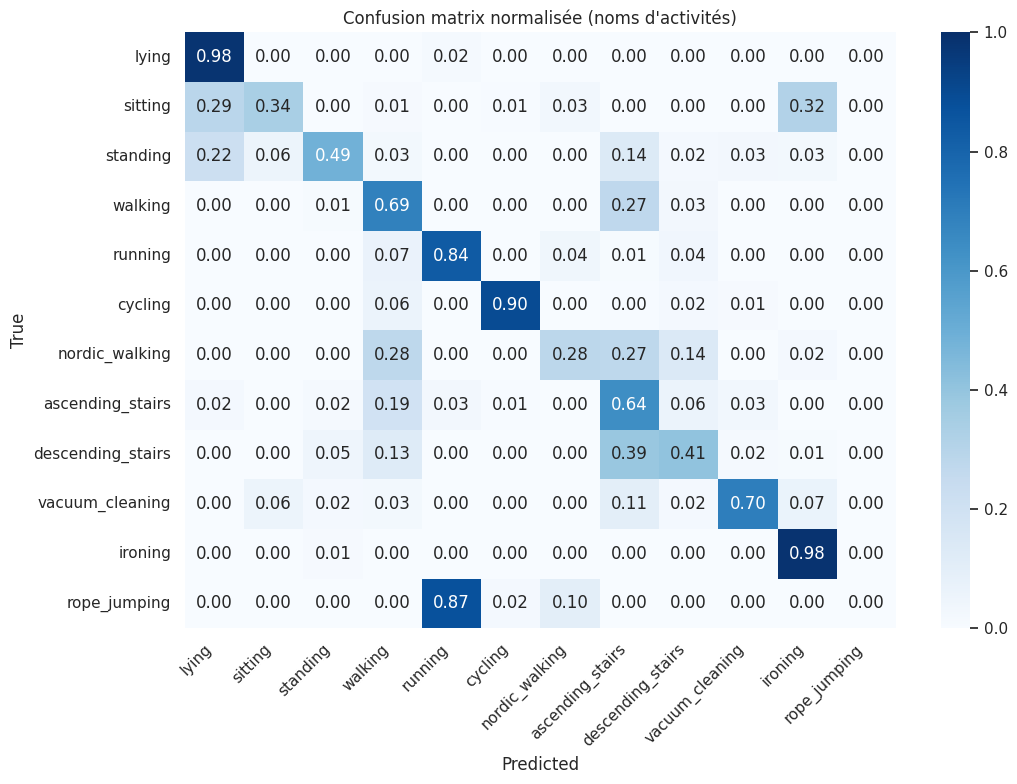

In [75]:
# Matrice normalisée avec noms d'activités (au lieu des IDs)
activity_labels = {
    1: "lying",
    2: "sitting",
    3: "standing",
    4: "walking",
    5: "running",
    6: "cycling",
    7: "nordic_walking",
    9: "watching_tv",
    10: "computer_work",
    11: "car_driving",
    12: "ascending_stairs",
    13: "descending_stairs",
    16: "vacuum_cleaning",
    17: "ironing",
    18: "folding_laundry",
    19: "house_cleaning",
    20: "playing_soccer",
    24: "rope_jumping"
}

labels = sorted(y_test.unique())
labels_name = [activity_labels.get(i, str(i)) for i in labels]

cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(11, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=labels_name,
    yticklabels=labels_name
)
plt.title("Confusion matrix normalisée (noms d'activités)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Regroupement de classe jugées trop proche 

In [76]:
# Regroupement des classes d'activités (rope_jumping avec running)
group_map = {
    2: "sitting-standing-ironing",   # sitting
    3: "sitting-standing-ironing",   # standing
    17: "sitting-standing-ironing",  # ironing
    12: "stairs",                    # ascending_stairs
    13: "stairs",                    # descending_stairs
    4: "walking-all",                # walking
    7: "walking-all",                # nordic_walking
    5: "running-rope",               # running
    24: "running-rope"               # rope_jumping
}

# Garde les autres classes telles quelles
activity_labels = {
    1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running", 6: "cycling",
    7: "nordic_walking", 12: "ascending_stairs", 13: "descending_stairs",
    16: "vacuum_cleaning", 17: "ironing", 24: "rope_jumping"
}

df_model["activity_group"] = df_model["activity_id"].map(group_map)
df_model["activity_group"] = df_model.apply(
    lambda r: r["activity_group"] if pd.notna(r["activity_group"]) else activity_labels.get(r["activity_id"], str(r["activity_id"])),
    axis=1
)

display(df_model[["activity_id", "activity_group"]].drop_duplicates().sort_values("activity_id"))
print(df_model["activity_group"].value_counts())


,activity_id,activity_group
2928,1,lying
30115,2,sitting-standing-ironing
53595,3,sitting-standing-ironing
223759,4,walking-all
312742,5,running-rope
283096,6,cycling
253175,7,walking-all
154281,12,stairs
173396,13,stairs
118760,16,vacuum_cleaning


activity_group
sitting-standing-ironing    613809
walking-all                 426868
stairs                      222160
lying                       192523
vacuum_cleaning             175353
cycling                     164600
running-rope                147559
Name: count, dtype: int64


## Random Forest

Train subjects: [np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(109)]
Test subjects : [np.int64(101), np.int64(107)]
X_train: (1460139, 40) | X_test: (482733, 40)

Classes train:
activity_group
sitting-standing-ironing    477507
walking-all                 321905
stairs                      162107
lying                       139725
vacuum_cleaning             130860
cycling                     118345
running-rope                109690
Name: count, dtype: int64

F1-macro: 0.7317
Balanced accuracy: 0.7196

Classification report:
                          precision    recall  f1-score   support

                 cycling       0.99      0.72      0.84     46255
                   lying       0.92      0.98      0.95     52798
            running-rope       0.94      0.83      0.88     37869
sitting-standing-ironing       0.83      0.80      0.82    136302
                  stairs       0.42      0.77      0.54     60053
         vacuum_cl

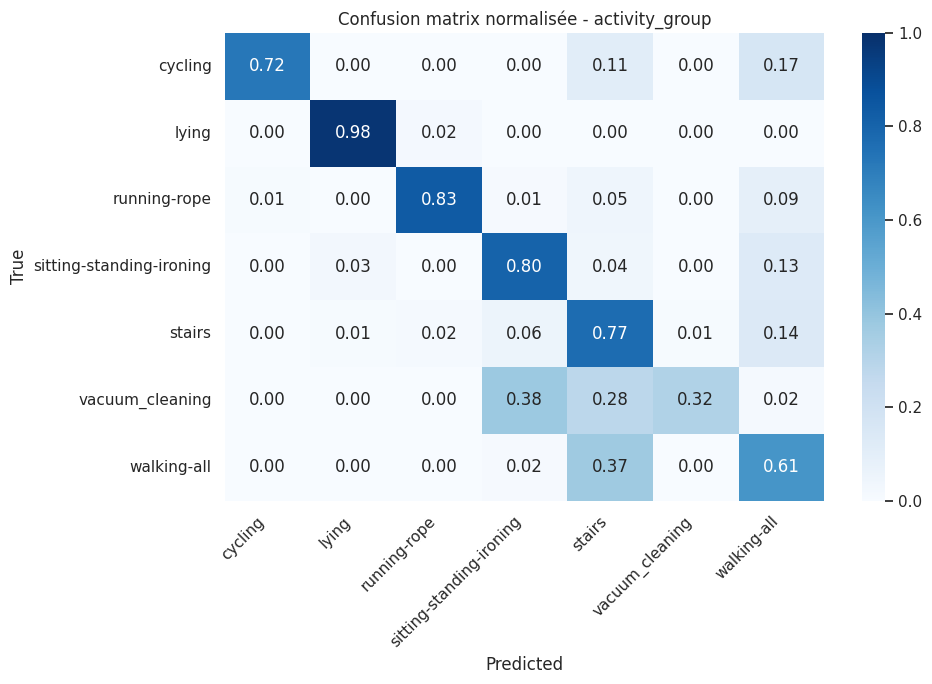

,importance
heart_rate,0.149728
hand_temp,0.112610
chest_temp,0.097402
ankle_temp,0.081106
chest_acc6_z,0.070812
chest_acc16_z,0.063293
chest_mag_z,0.054143
chest_mag_x,0.031494
chest_mag_y,0.027134
chest_acc16_y,0.027006


In [77]:
# Entraînement RandomForest avec la cible regroupée "activity_group"

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 0) Vérification
if "activity_group" not in df_model.columns:
    raise ValueError("La colonne 'activity_group' est absente. Crée-la avant l'entraînement.")

# 1) Split 7/2 par sujet (reproductible)
subjects = sorted(df_model["subject_id"].dropna().unique())
rng = np.random.default_rng(42)
test_subjects = sorted(rng.choice(subjects, size=2, replace=False))
train_subjects = sorted([s for s in subjects if s not in test_subjects])

train_mask = df_model["subject_id"].isin(train_subjects)
test_mask = df_model["subject_id"].isin(test_subjects)

# 2) Features / cible
feature_cols = [c for c in df_model.columns if c not in ["activity_id", "activity_group", "subject_id", "timestamp"]]
X_train = df_model.loc[train_mask, feature_cols].copy()
X_test  = df_model.loc[test_mask, feature_cols].copy()

y_train = df_model.loc[train_mask, "activity_group"].copy()
y_test  = df_model.loc[test_mask, "activity_group"].copy()

print("Train subjects:", train_subjects)
print("Test subjects :", test_subjects)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("\nClasses train:")
print(y_train.value_counts())

# 3) Modèle
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 4) Résultats
f1 = f1_score(y_test, y_pred, average="macro")
bacc = balanced_accuracy_score(y_test, y_pred)

print(f"\nF1-macro: {f1:.4f}")
print(f"Balanced accuracy: {bacc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 5) Confusion matrix normalisée (robuste)
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=labels, yticklabels=labels, vmin=0, vmax=1
)
plt.title("Confusion matrix normalisée - activity_group")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6) Top features importantes
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(importances.head(15).to_frame("importance"))


- Les groupes proches en pattern de mouvement se mélangent, c’est attendu.
- Le regroupement sitting-standing-ironing est peut-être trop large et “attire” vacuum_cleaning.
- walking-all est proche biomécaniquement de stairs.

Nouvelle tentative :

- Ajouter features temporelles par fenêtre (mean/std/energy sur 2-5s).
- Garder vacuum_cleaning séparé mais envisager de ne pas fusionner ironing avec sitting/standing.
- Tester XGBoost en comparaison (souvent meilleur sur ces frontières).


In [78]:
# 1) Nouveau regroupement (ironing séparé)
group_map_v2 = {
    2: "sitting-standing",   # sitting
    3: "sitting-standing",   # standing
    12: "stairs",
    13: "stairs",
    4: "walking-all",
    7: "walking-all",
    5: "running-rope",
    24: "running-rope"
}

activity_labels = {
    1: "lying", 2: "sitting", 3: "standing", 4: "walking", 5: "running", 6: "cycling",
    7: "nordic_walking", 12: "ascending_stairs", 13: "descending_stairs",
    16: "vacuum_cleaning", 17: "ironing", 24: "rope_jumping"
}

df_exp = df_model.copy()
df_exp["activity_group"] = df_exp["activity_id"].map(group_map_v2)
df_exp["activity_group"] = df_exp.apply(
    lambda r: r["activity_group"] if pd.notna(r["activity_group"]) else activity_labels.get(r["activity_id"], str(r["activity_id"])),
    axis=1
)

display(df_exp[["activity_id", "activity_group"]].drop_duplicates().sort_values("activity_id"))
print(df_exp["activity_group"].value_counts())
￼



,activity_id,activity_group
2928,1,lying
30115,2,sitting-standing
53595,3,sitting-standing
223759,4,walking-all
312742,5,running-rope
283096,6,cycling
253175,7,walking-all
154281,12,stairs
173396,13,stairs
118760,16,vacuum_cleaning


activity_group
walking-all         426868
sitting-standing    375119
ironing             238690
stairs              222160
lying               192523
vacuum_cleaning     175353
cycling             164600
running-rope        147559
Name: count, dtype: int64


## Définition de la fenetre temporelle

In [79]:
# 2) Fenêtrage temporel simple + features statistiques
#    (sur protocol déjà nettoyé, sans orient, sans NaN)
import numpy as np
import pandas as pd

dfw = df_exp.sort_values(["subject_id", "timestamp"]).copy()

feature_base = [c for c in dfw.columns if c not in ["activity_id", "activity_group", "subject_id", "timestamp"]]
window_size = 3000   # ~5 seconde à 100 Hz
step_size = 1500      # overlap 50%

rows = []
for sid, g in dfw.groupby("subject_id"):
    g = g.reset_index(drop=True)
    n = len(g)
    for start in range(0, n - window_size + 1, step_size):
        w = g.iloc[start:start + window_size]

        # cible = classe majoritaire de la fenêtre
        y_win = w["activity_group"].mode().iloc[0]

        feat = {
            "subject_id": sid,
            "activity_group": y_win
        }

        # stats compactes
        for col in feature_base:
            s = w[col]
            feat[f"{col}__mean"] = s.mean()
            feat[f"{col}__std"] = s.std()
            feat[f"{col}__min"] = s.min()
            feat[f"{col}__max"] = s.max()

        rows.append(feat)

df_win = pd.DataFrame(rows)
print("df_win shape:", df_win.shape)
display(df_win.head(2))


df_win shape: (1282, 162)


,subject_id,activity_group,heart_rate__mean,heart_rate__std,heart_rate__min,heart_rate__max,hand_temp__mean,hand_temp__std,hand_temp__min,hand_temp__max,hand_acc16_x__mean,hand_acc16_x__std,hand_acc16_x__min,hand_acc16_x__max,hand_acc16_y__mean,hand_acc16_y__std,hand_acc16_y__min,hand_acc16_y__max,hand_acc16_z__mean,hand_acc16_z__std,hand_acc16_z__min,hand_acc16_z__max,hand_acc6_x__mean,hand_acc6_x__std,hand_acc6_x__min,hand_acc6_x__max,hand_acc6_y__mean,hand_acc6_y__std,hand_acc6_y__min,hand_acc6_y__max,hand_acc6_z__mean,hand_acc6_z__std,hand_acc6_z__min,hand_acc6_z__max,hand_gyro_x__mean,hand_gyro_x__std,hand_gyro_x__min,hand_gyro_x__max,hand_gyro_y__mean,hand_gyro_y__std,hand_gyro_y__min,hand_gyro_y__max,hand_gyro_z__mean,hand_gyro_z__std,hand_gyro_z__min,hand_gyro_z__max,hand_mag_x__mean,hand_mag_x__std,hand_mag_x__min,hand_mag_x__max,hand_mag_y__mean,hand_mag_y__std,hand_mag_y__min,hand_mag_y__max,hand_mag_z__mean,hand_mag_z__std,hand_mag_z__min,hand_mag_z__max,chest_temp__mean,chest_temp__std,...,chest_mag_y__mean,chest_mag_y__std,chest_mag_y__min,chest_mag_y__max,chest_mag_z__mean,chest_mag_z__std,chest_mag_z__min,chest_mag_z__max,ankle_temp__mean,ankle_temp__std,ankle_temp__min,ankle_temp__max,ankle_acc16_x__mean,ankle_acc16_x__std,ankle_acc16_x__min,ankle_acc16_x__max,ankle_acc16_y__mean,ankle_acc16_y__std,ankle_acc16_y__min,ankle_acc16_y__max,ankle_acc16_z__mean,ankle_acc16_z__std,ankle_acc16_z__min,ankle_acc16_z__max,ankle_acc6_x__mean,ankle_acc6_x__std,ankle_acc6_x__min,ankle_acc6_x__max,ankle_acc6_y__mean,ankle_acc6_y__std,ankle_acc6_y__min,ankle_acc6_y__max,ankle_acc6_z__mean,ankle_acc6_z__std,ankle_acc6_z__min,ankle_acc6_z__max,ankle_gyro_x__mean,ankle_gyro_x__std,ankle_gyro_x__min,ankle_gyro_x__max,ankle_gyro_y__mean,ankle_gyro_y__std,ankle_gyro_y__min,ankle_gyro_y__max,ankle_gyro_z__mean,ankle_gyro_z__std,ankle_gyro_z__min,ankle_gyro_z__max,ankle_mag_x__mean,ankle_mag_x__std,ankle_mag_x__min,ankle_mag_x__max,ankle_mag_y__mean,ankle_mag_y__std,ankle_mag_y__min,ankle_mag_y__max,ankle_mag_z__mean,ankle_mag_z__std,ankle_mag_z__min,ankle_mag_z__max
0,101,lying,103.470667,2.022005,100.0,107.0,30.546521,0.086549,30.3750,30.6875,1.209798,4.202209,-14.090400,6.8565,5.917443,2.432650,-7.140180,12.45170,5.570645,2.534330,-4.15293,10.33540,1.209200,4.232711,-14.050700,6.83359,5.901069,2.433267,-7.300870,12.53970,5.669755,2.531717,-4.13927,10.32840,0.047111,0.530689,-2.53720,3.05396,-0.095213,0.474602,-2.641790,1.287300,0.003167,0.612568,-4.64501,2.28479,-11.480311,16.916033,-32.4044,66.2154,-6.392204,39.539284,-69.7868,53.7261,-32.557574,27.016865,-59.7763,34.8403,32.353917,0.086094,...,-12.461749,28.926811,-58.31300,12.9869,-17.802849,47.350386,-58.4899,63.7456,30.920833,0.090778,30.7500,31.0625,3.356677,4.878186,-3.390960,15.25270,-5.590598,3.577459,-29.71820,20.62360,-3.937790,2.751169,-12.8712,0.43618,3.302468,4.873134,-3.390340,15.1014,-5.478068,3.526056,-22.76410,2.17696,-3.664950,2.819742,-12.2998,0.819487,-0.007111,0.210086,-2.609650,1.548180,-0.007782,0.206857,-1.152890,1.813310,0.063750,0.410929,-0.721738,3.461520,-32.061642,22.970679,-117.2680,-10.6693,13.038056,40.906362,-57.5572,46.0951,-26.068525,22.576162,-60.5193,-3.82731
1,101,lying,100.026000,4.886166,93.0,107.0,30.677208,0.072241,30.5625,30.8125,5.091436,2.176851,0.018591,6.8565,5.087485,0.468394,0.261184,7.20895,6.212466,0.840525,4.67432,9.08848,5.121436,2.206394,0.041434,6.83359,5.071282,0.465759,0.192235,7.24538,6.288440,0.841512,4.85834,9.15927,0.018107,0.199805,-1.13754,3.05396,-0.001526,0.091792,-0.838578,0.805072,0.023615,0.214774,-0.29302,1.84625,-16.868046,6.638295,-32.4044,-12.0073,15.971946,2.203682,13.1330,33.3368,-55.280895,6.892471,-60.3737,-38.5674,32.483000,0.069908,...,10.860004,0.695650,7.30473,12.9869,-54.393593,0.511419,-55.9224,-52.4790,31.061979,0.080367,30.9375,31.1875,-0.604070,0.056270,-0.841604,-0.34325,-7.842773,0.169851,-8.45641,-7.38471,-6.345369,0.237120,-6.8059,-5.21945,-0.653516,0.027626,-0.820277,-0.5207,-7.717417,0.1543

F1-macro: 0.9662
Balanced accuracy: 0.9704
                  precision    recall  f1-score   support

         cycling       0.91      1.00      0.95        30
         ironing       0.87      0.97      0.92        35
           lying       1.00      1.00      1.00        35
    running-rope       1.00      0.96      0.98        24
sitting-standing       0.98      0.91      0.94        55
          stairs       0.95      1.00      0.97        39
 vacuum_cleaning       1.00      0.97      0.98        30
     walking-all       1.00      0.96      0.98        71

        accuracy                           0.97       319
       macro avg       0.96      0.97      0.97       319
    weighted avg       0.97      0.97      0.97       319



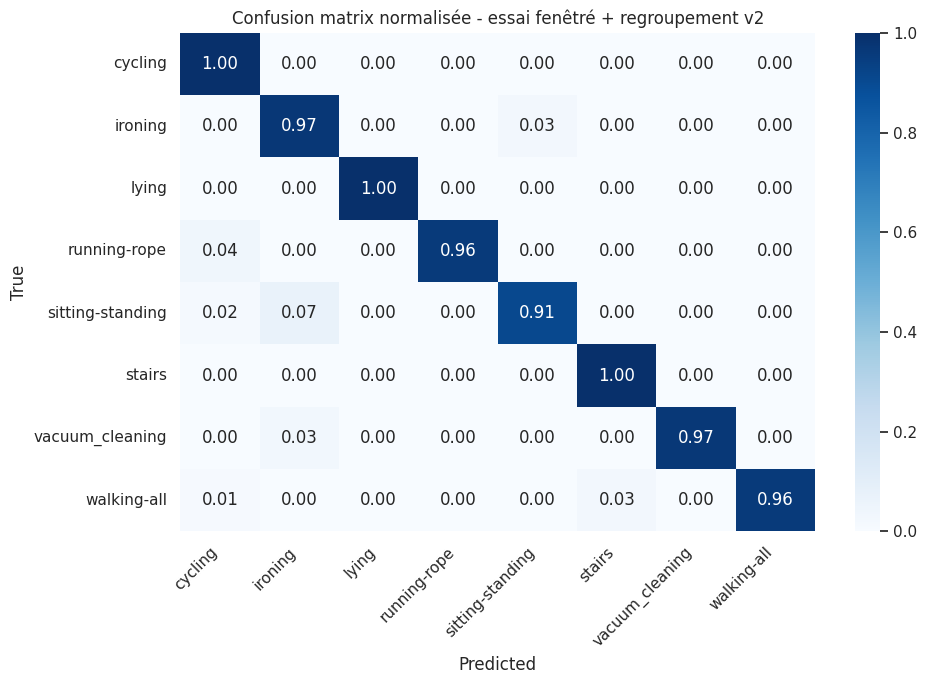

In [80]:
# 3) Split 7/2 sujets + RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

subjects = sorted(df_win["subject_id"].dropna().unique())
rng = np.random.default_rng(42)
test_subjects = sorted(rng.choice(subjects, size=2, replace=False))
train_subjects = sorted([s for s in subjects if s not in test_subjects])

train_mask = df_win["subject_id"].isin(train_subjects)
test_mask = df_win["subject_id"].isin(test_subjects)

X_train = df_win.loc[train_mask].drop(columns=["subject_id", "activity_group"])
X_test  = df_win.loc[test_mask].drop(columns=["subject_id", "activity_group"])
y_train = df_win.loc[train_mask, "activity_group"]
y_test  = df_win.loc[test_mask, "activity_group"]

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"F1-macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels, vmin=0, vmax=1)
plt.title("Confusion matrix normalisée - essai fenêtré + regroupement v2")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Test avec XGBoost

F1-macro: 0.9390
Balanced accuracy: 0.9488
                  precision    recall  f1-score   support

         cycling       0.91      1.00      0.95        30
         ironing       0.74      1.00      0.85        35
           lying       0.92      1.00      0.96        35
    running-rope       1.00      0.96      0.98        24
sitting-standing       1.00      0.73      0.84        55
          stairs       0.95      1.00      0.97        39
 vacuum_cleaning       1.00      0.93      0.97        30
     walking-all       1.00      0.97      0.99        71

        accuracy                           0.94       319
       macro avg       0.94      0.95      0.94       319
    weighted avg       0.95      0.94      0.94       319



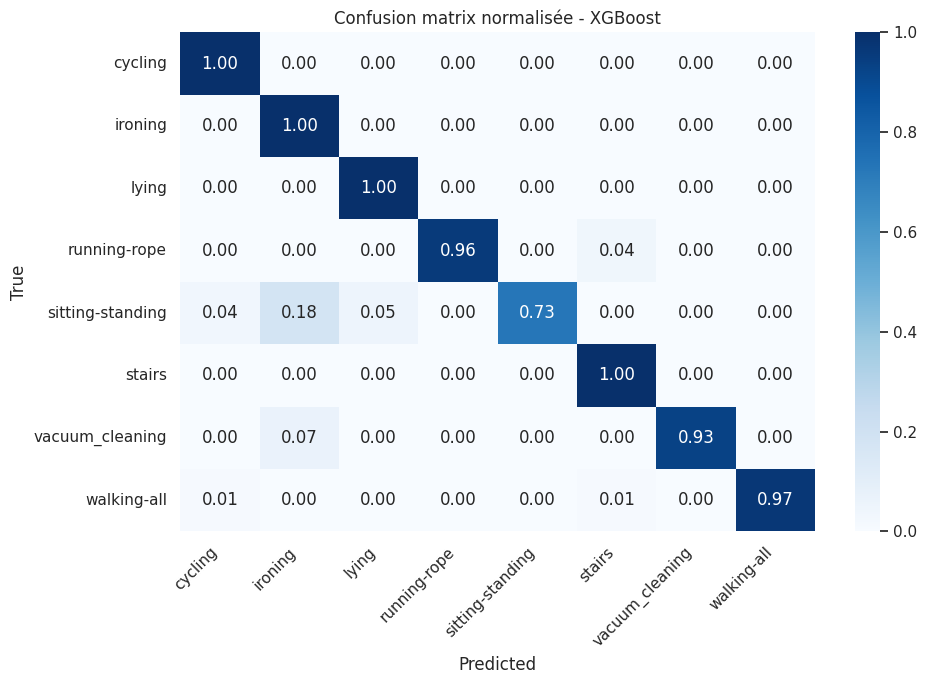

In [81]:
# XGBoost sur les features fenêtrées (df_win)
# pip install xgboost si besoin

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1) Split 7/2 par sujet (même logique)
subjects = sorted(df_win["subject_id"].dropna().unique())
rng = np.random.default_rng(42)
test_subjects = sorted(rng.choice(subjects, size=2, replace=False))
train_subjects = sorted([s for s in subjects if s not in test_subjects])

train_mask = df_win["subject_id"].isin(train_subjects)
test_mask = df_win["subject_id"].isin(test_subjects)

X_train = df_win.loc[train_mask].drop(columns=["subject_id", "activity_group"]).copy()
X_test  = df_win.loc[test_mask].drop(columns=["subject_id", "activity_group"]).copy()

y_train_raw = df_win.loc[train_mask, "activity_group"].copy()
y_test_raw  = df_win.loc[test_mask, "activity_group"].copy()

# 2) Encodage labels (XGBoost attend du numérique)
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

# 3) Modèle XGBoost
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist",   # efficace CPU/GPU
    device="cuda"         # RTX 3090 si xgboost GPU dispo; sinon passe en "cpu"
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

# 4) Métriques
f1 = f1_score(y_test, y_pred, average="macro")
bacc = balanced_accuracy_score(y_test, y_pred)

print(f"F1-macro: {f1:.4f}")
print(f"Balanced accuracy: {bacc:.4f}")
print(classification_report(le.inverse_transform(y_test), le.inverse_transform(y_pred), zero_division=0))

# 5) Confusion matrix normalisée
labels_idx = np.arange(len(le.classes_))
cm = confusion_matrix(y_test, y_pred, labels=labels_idx)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title("Confusion matrix normalisée - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Train subjects: [np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(108), np.int64(109)]
Test subjects : [np.int64(101), np.int64(107)]
X_train: (963, 160) | X_test: (319, 160)

F1-macro: 0.8886
Balanced accuracy: 0.8940

Classification report:
                  precision    recall  f1-score   support

         cycling       0.86      1.00      0.92        30
         ironing       0.67      0.97      0.79        35
           lying       1.00      0.97      0.99        35
    running-rope       1.00      0.79      0.88        24
sitting-standing       0.95      0.67      0.79        55
          stairs       0.79      0.95      0.86        39
 vacuum_cleaning       1.00      0.87      0.93        30
     walking-all       0.97      0.93      0.95        71

        accuracy                           0.89       319
       macro avg       0.90      0.89      0.89       319
    weighted avg       0.91      0.89      0.89       319



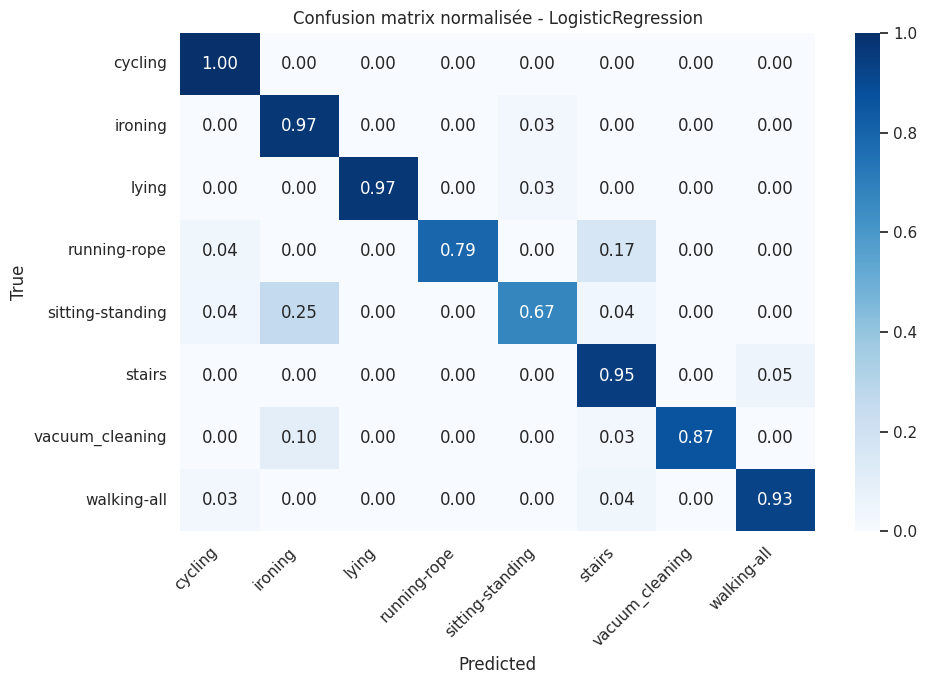

In [83]:
# Régression logistique (multiclasse) - version compatible large (sans multi_class, sans n_jobs)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1) Split 7/2 par sujet (reproductible)
subjects = sorted(df_win["subject_id"].dropna().unique())
rng = np.random.default_rng(42)
test_subjects = sorted(rng.choice(subjects, size=2, replace=False))
train_subjects = sorted([s for s in subjects if s not in test_subjects])

train_mask = df_win["subject_id"].isin(train_subjects)
test_mask = df_win["subject_id"].isin(test_subjects)

X_train = df_win.loc[train_mask].drop(columns=["subject_id", "activity_group"]).copy()
X_test  = df_win.loc[test_mask].drop(columns=["subject_id", "activity_group"]).copy()
y_train = df_win.loc[train_mask, "activity_group"].copy()
y_test  = df_win.loc[test_mask, "activity_group"].copy()

print("Train subjects:", train_subjects)
print("Test subjects :", test_subjects)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# 2) Pipeline: scaling + logistic regression
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

# 3) Entraînement + prédiction
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

# 4) Résultats
lr_f1 = f1_score(y_test, y_pred_lr, average="macro")
lr_bacc = balanced_accuracy_score(y_test, y_pred_lr)

print(f"\nF1-macro: {lr_f1:.4f}")
print(f"Balanced accuracy: {lr_bacc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

# 5) Confusion matrix normalisée
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=labels, yticklabels=labels, vmin=0, vmax=1
)
plt.title("Confusion matrix normalisée - LogisticRegression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [98]:
# Tableau comparatif des 3 modèles (sans relancer d'entraînement)
import pandas as pd
import numpy as np

rows = []

def add_row(name, f1_var, bacc_var):
    if f1_var in globals() and bacc_var in globals():
        rows.append({
            "model": name,
            "f1_macro": round(float(globals()[f1_var]), 4),
            "balanced_accuracy": round(float(globals()[bacc_var]), 4)
        })

add_row("RandomForest", "rf_f1", "rf_bacc")
add_row("XGBoost", "xgb_f1", "xgb_bacc")
add_row("LogisticRegression", "lr_f1", "lr_bacc")

if len(rows) == 0:
    print("Aucune métrique trouvée. Variables attendues: rf_f1/rf_bacc, xgb_f1/xgb_bacc, lr_f1/lr_bacc")
else:
    results_3_models = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
    display(results_3_models)


,model,f1_macro,balanced_accuracy
0,LogisticRegression,0.8886,0.8940
1,RandomForest,0.8355,0.8484
2,XGBoost,0.8150,0.8254


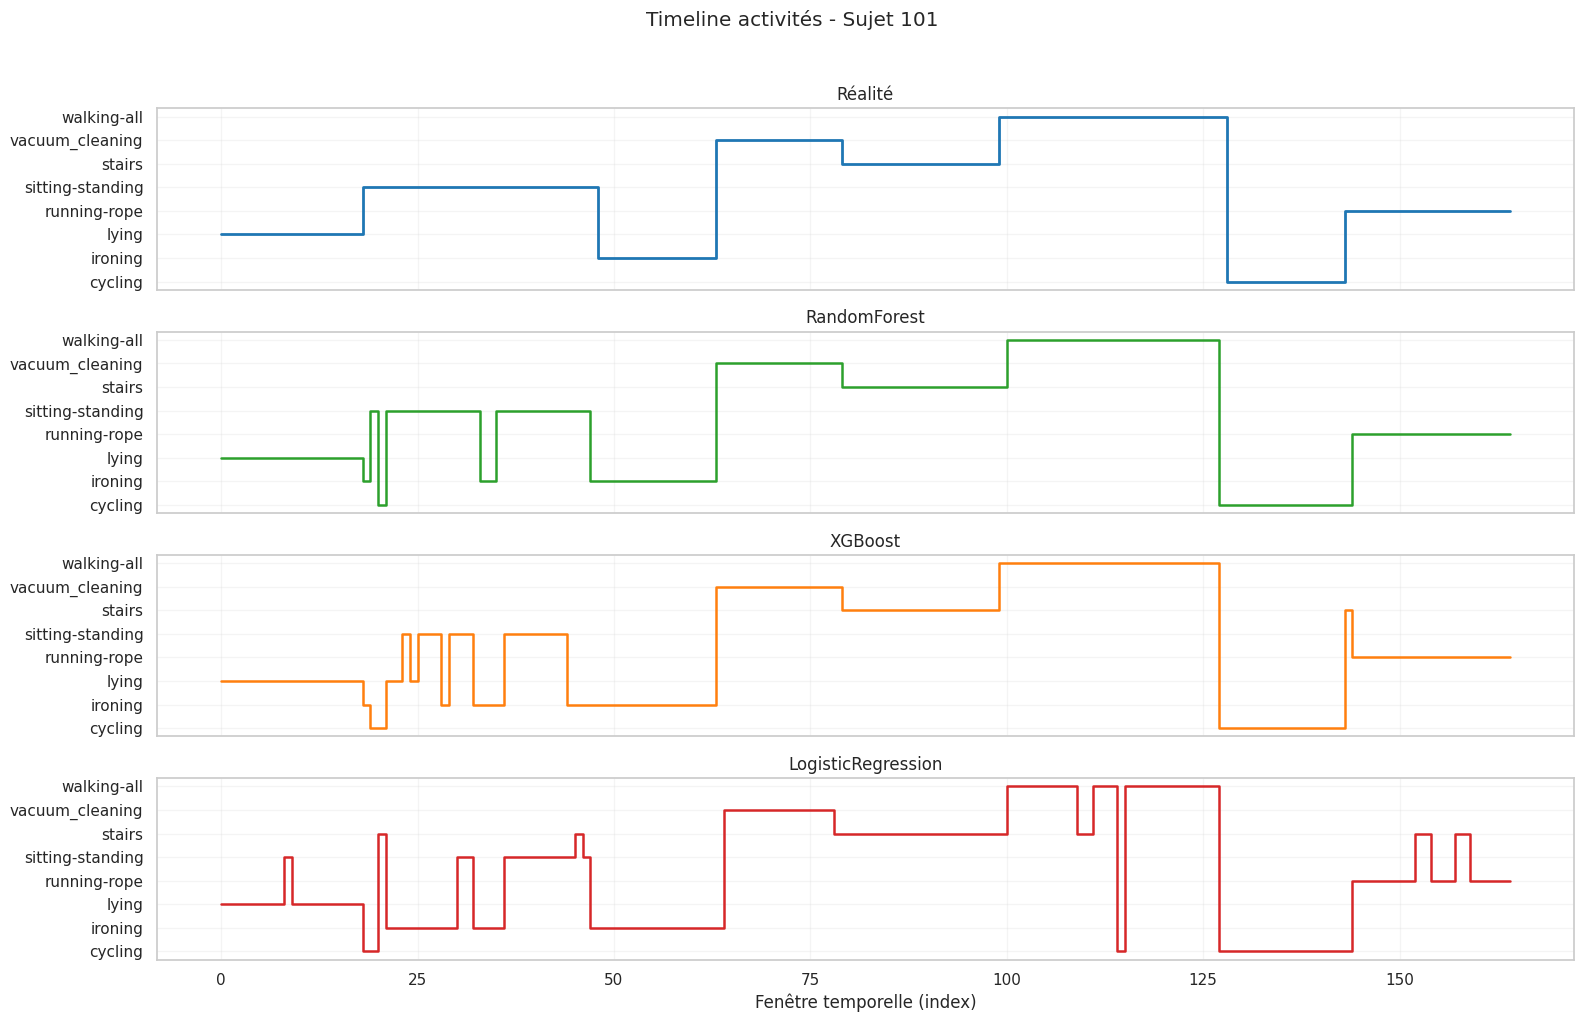

In [85]:
# 4 timelines superposées pour le sujet 101:
# 1) Réalité
# 2) RandomForest
# 3) XGBoost
# 4) LogisticRegression

import numpy as np
import matplotlib.pyplot as plt

subject_id_to_plot = 101

df_101 = df_win[df_win["subject_id"] == subject_id_to_plot].copy().reset_index(drop=True)

if df_101.empty:
    print(f"Aucune donnée pour le sujet {subject_id_to_plot}.")
else:
    X_101 = df_101.drop(columns=["subject_id", "activity_group"])
    y_true = df_101["activity_group"].astype(str).values

    # Vérifie que les 3 modèles existent déjà
    missing_models = [m for m in ["rf", "xgb", "logreg"] if m not in globals()]
    if missing_models:
        print(f"Modèles manquants en mémoire: {missing_models}")
    else:
        y_rf = rf.predict(X_101).astype(str)
        y_xgb = le.inverse_transform(xgb.predict(X_101)).astype(str) if "le" in globals() else xgb.predict(X_101).astype(str)
        y_lr = logreg.predict(X_101).astype(str)

        # Référentiel commun de labels (pour même axe Y sur les 4 lignes)
        labels = sorted(np.unique(np.concatenate([y_true, y_rf, y_xgb, y_lr])))
        label_to_int = {lab: i for i, lab in enumerate(labels)}

        y_true_i = np.array([label_to_int[v] for v in y_true])
        y_rf_i   = np.array([label_to_int[v] for v in y_rf])
        y_xgb_i  = np.array([label_to_int[v] for v in y_xgb])
        y_lr_i   = np.array([label_to_int[v] for v in y_lr])

        x = np.arange(len(df_101))

        fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True, sharey=True)

        axes[0].step(x, y_true_i, where="post", linewidth=2.0, color="#1f77b4")
        axes[0].set_title("Réalité")

        axes[1].step(x, y_rf_i, where="post", linewidth=1.8, color="#2ca02c")
        axes[1].set_title("RandomForest")

        axes[2].step(x, y_xgb_i, where="post", linewidth=1.8, color="#ff7f0e")
        axes[2].set_title("XGBoost")

        axes[3].step(x, y_lr_i, where="post", linewidth=1.8, color="#d62728")
        axes[3].set_title("LogisticRegression")

        for ax in axes:
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels(labels)
            ax.grid(alpha=0.2)

        axes[-1].set_xlabel("Fenêtre temporelle (index)")
        fig.suptitle(f"Timeline activités - Sujet {subject_id_to_plot}", y=1.02)
        plt.tight_layout()
        plt.show()


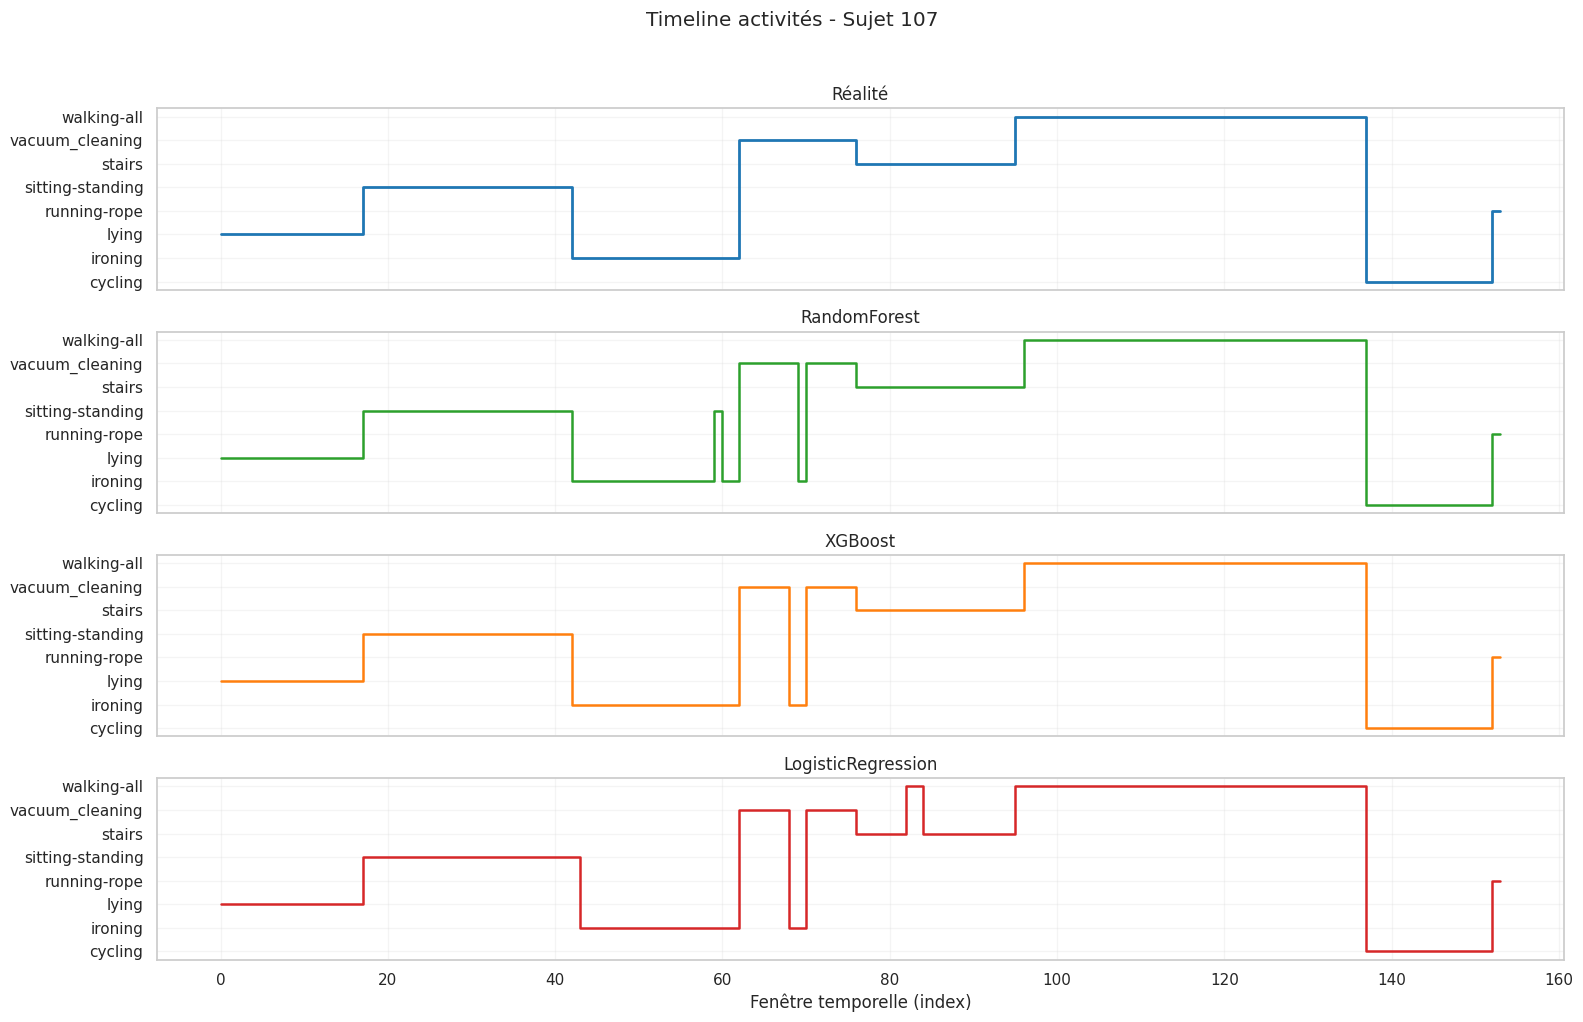

In [86]:
# 4 timelines superposées pour le sujet 107:
# 1) Réalité
# 2) RandomForest
# 3) XGBoost
# 4) LogisticRegression

import numpy as np
import matplotlib.pyplot as plt

subject_id_to_plot = 107

df_101 = df_win[df_win["subject_id"] == subject_id_to_plot].copy().reset_index(drop=True)

if df_101.empty:
    print(f"Aucune donnée pour le sujet {subject_id_to_plot}.")
else:
    X_101 = df_101.drop(columns=["subject_id", "activity_group"])
    y_true = df_101["activity_group"].astype(str).values

    # Vérifie que les 3 modèles existent déjà
    missing_models = [m for m in ["rf", "xgb", "logreg"] if m not in globals()]
    if missing_models:
        print(f"Modèles manquants en mémoire: {missing_models}")
    else:
        y_rf = rf.predict(X_101).astype(str)
        y_xgb = le.inverse_transform(xgb.predict(X_101)).astype(str) if "le" in globals() else xgb.predict(X_101).astype(str)
        y_lr = logreg.predict(X_101).astype(str)

        # Référentiel commun de labels (pour même axe Y sur les 4 lignes)
        labels = sorted(np.unique(np.concatenate([y_true, y_rf, y_xgb, y_lr])))
        label_to_int = {lab: i for i, lab in enumerate(labels)}

        y_true_i = np.array([label_to_int[v] for v in y_true])
        y_rf_i   = np.array([label_to_int[v] for v in y_rf])
        y_xgb_i  = np.array([label_to_int[v] for v in y_xgb])
        y_lr_i   = np.array([label_to_int[v] for v in y_lr])

        x = np.arange(len(df_101))

        fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True, sharey=True)

        axes[0].step(x, y_true_i, where="post", linewidth=2.0, color="#1f77b4")
        axes[0].set_title("Réalité")

        axes[1].step(x, y_rf_i, where="post", linewidth=1.8, color="#2ca02c")
        axes[1].set_title("RandomForest")

        axes[2].step(x, y_xgb_i, where="post", linewidth=1.8, color="#ff7f0e")
        axes[2].set_title("XGBoost")

        axes[3].step(x, y_lr_i, where="post", linewidth=1.8, color="#d62728")
        axes[3].set_title("LogisticRegression")

        for ax in axes:
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels(labels)
            ax.grid(alpha=0.2)

        axes[-1].set_xlabel("Fenêtre temporelle (index)")
        fig.suptitle(f"Timeline activités - Sujet {subject_id_to_plot}", y=1.02)
        plt.tight_layout()
        plt.show()


## Conclusion

Dans cette dernière partie, nous avons finalisé une baseline de **détection d’activité** sur PAMAP2 en restant sur un pipeline simple et lisible.

### Ce qui a été fait
- Nettoyage des données:
  - suppression des colonnes `*_orient_*` (invalides selon la documentation PAMAP2),
  - imputation des valeurs manquantes (médiane),
  - exclusion de `activity_id = 0` (transitions).
- Regroupement des classes pour une cible métier plus stable:
  - `sitting-standing` (avec séparation de `ironing` dans les essais finaux),
  - `stairs` (montée + descente),
  - `walking-all` (walking + nordic),
  - `running-rope` (running + rope_jumping).
- Découpage temporel en fenêtres glissantes et extraction de features statistiques (`mean/std/min/max`).
- Entraînement et comparaison de 3 modèles:
  - RandomForest,
  - XGBoost,
  - LogisticRegression.
- Évaluation par matrice de confusion normalisée, tableau des métriques et timeline sujet (réalité vs prédictions).

### Résultats principaux
- Les essais avec petites fenêtres étaient plus bruités (beaucoup de changements de classe).
- Le passage à des fenêtres plus longues (jusqu’à 30s) a nettement stabilisé les prédictions sur la timeline.
- Les modèles suivent correctement la dynamique globale des activités, avec des erreurs surtout autour des transitions ou entre classes proches.

### Interprétation
- Le fenêtrage temporel est un levier majeur de performance et de stabilité.
- Le retrait de `timestamp` dans l’entraînement a permis d’éviter un biais lié à l’ordre du protocole.
- Les confusions restantes sont cohérentes biomécaniquement (activités proches en pattern).

### Suite possible
- Tester plusieurs tailles de fenêtres (10s, 15s, 30s) de manière systématique.
- Ajouter quelques features temporelles/fréquentielles supplémentaires.
- Valider la robustesse sur plusieurs splits par sujet (GroupKFold / LOSO).
